## Import Libraries 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

C:\Users\shivk\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Data loading and EDA: null check, descriptive statistics, pairplot of all features 

In [5]:
df = pd.read_csv("advertising.csv")  #source = https://www.kaggle.com/datasets/yasserh/advertising-sales-dataset

In [6]:
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [7]:
print('1:', df.shape)
print('2:', df.info())
print('3:', df.describe())
print('4:', df.isnull().sum())

1: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales                    200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
2: None
3:        Unnamed: 0  TV Ad Budget ($)  Radio Ad Budget ($)  \
count  200.000000        200.000000           200.000000   
mean   100.500000        147.042500            23.264000   
std     57.879185         85.854236            14.846809   
min      1.000000          0.700000             0.000000   
25%     50.750000         74.375000             9.975000   
50%    100.500000        149.750000            22.900000   
75%    150.250000        218.825000 

In [8]:
df = df.drop(columns=["Unnamed: 0"])

In [9]:
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [10]:
df.duplicated().sum()

np.int64(0)

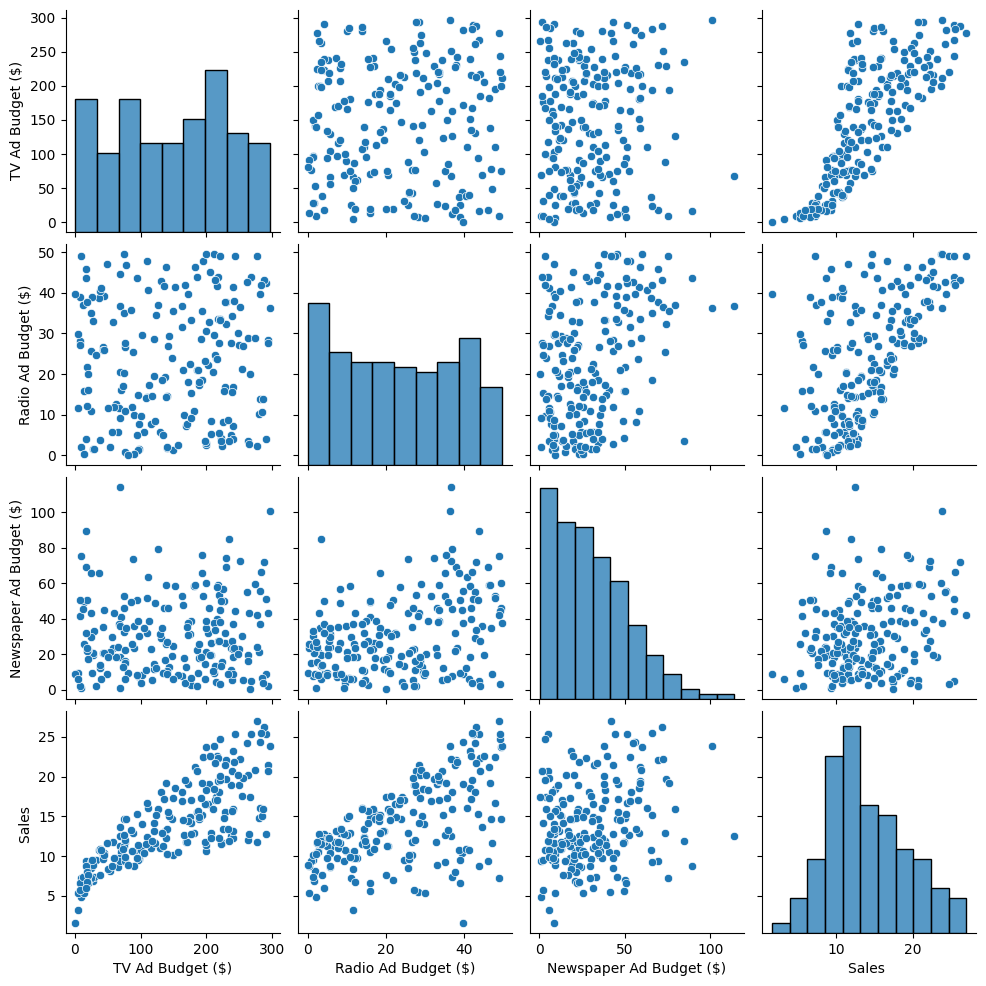

In [11]:
sns.pairplot(df)
plt.show()

In [ ]:
### Observation

The pairplot shows the relationship between all advertising channels and sales.

- TV advertising has the strongest positive relationship with Sales.
- Radio advertising also shows a positive relationship, but weaker than TV.
- Newspaper advertising has a very weak relationship with Sales.
- No obvious missing values or abnormal patterns are visible.

## Correlation matrix heatmap

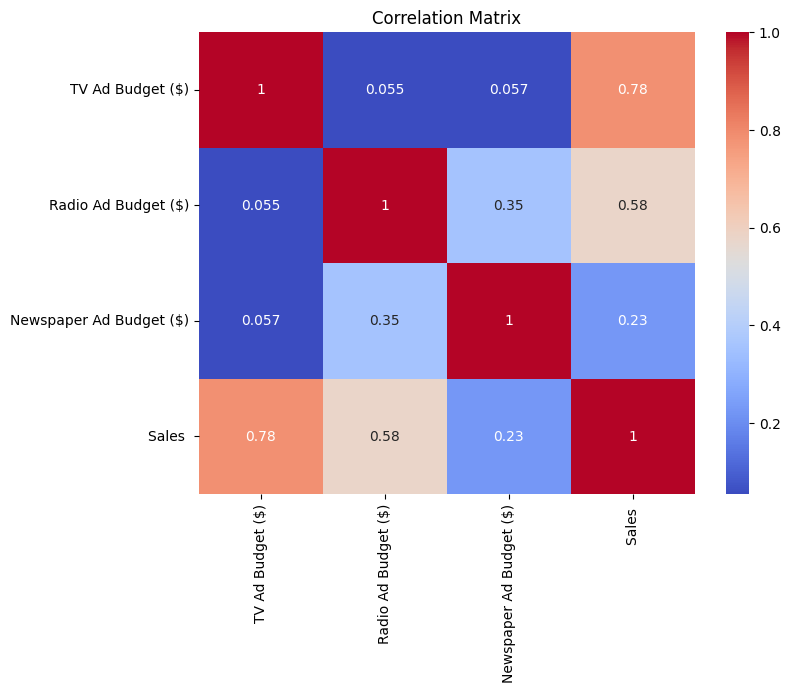

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [ ]:
### Observation

The correlation matrix indicates that TV advertising has the highest correlation with Sales (0.78), making it the most influential feature.

Radio advertising has a moderate positive correlation (0.58), while Newspaper advertising has a weak correlation (0.23).

This suggests that TV and Radio budgets are better predictors of Sales than Newspaper advertising.

## Individual scatter plots: Sales vs. TV spend


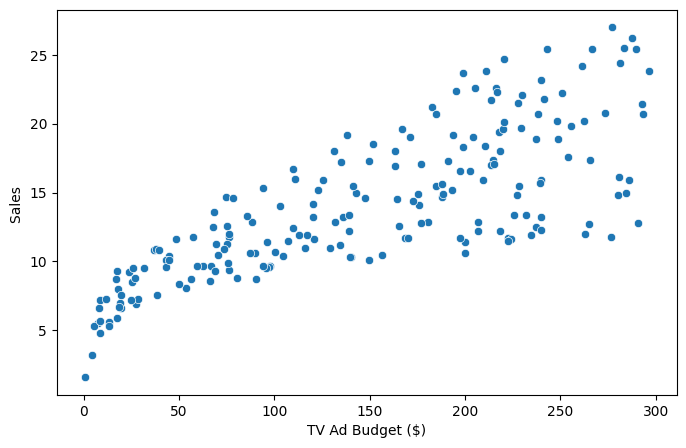

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="TV Ad Budget ($)",
    y="Sales "
)

plt.show()

In [ ]:
### Observation

There is a strong positive linear relationship between TV advertising budget and Sales.

As TV advertising expenditure increases, Sales generally increase as well.

This indicates that TV advertising is one of the most important factors affecting product sales.

## Sales vs. Radio spend

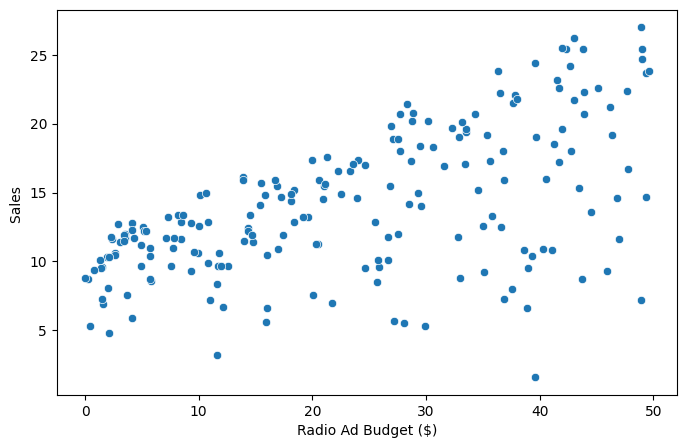

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Radio Ad Budget ($)",
    y="Sales "
)

plt.show()

In [ ]:
### Observation

Radio advertising also shows a positive relationship with Sales.

However, the data points are more scattered compared to TV advertising, indicating a moderate influence on Sales.

## Sales vs. Newspaper spend

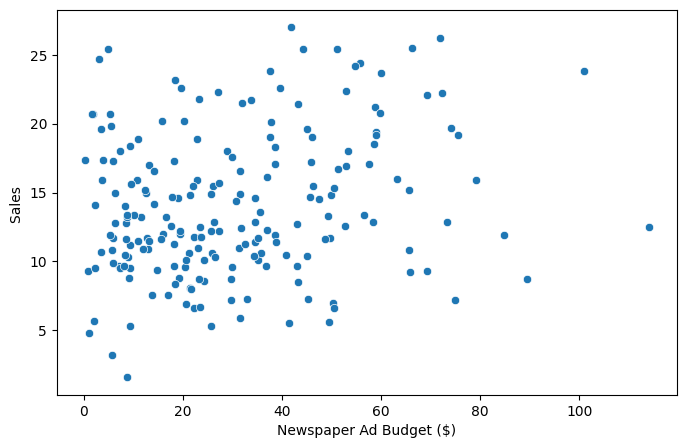

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Newspaper Ad Budget ($)",
    y="Sales "
)

plt.show()

In [ ]:
### Observation

Newspaper advertising shows a weak relationship with Sales.

The points are widely scattered, suggesting that increasing Newspaper advertising alone does not significantly increase Sales.

## Train/test split 

In [23]:
X = df.drop(columns=["Sales ($)"])

y = df["Sales ($)"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train a  Linear Regression  model as the baseline

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred = lr.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 :", r2_score(y_test, y_pred))

MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE: 1.78159966153345
R2 : 0.899438024100912


## Train at least one additional model (e.g., Random Forest Regressor, Polynomial Regression) 

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [29]:
rf_pred = rf.predict(X_test)

## Evaluate using: MAE, RMSE, R² score

In [30]:
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred) ** 0.5)
print("R2 :", r2_score(y_test, rf_pred))

MAE : 0.6200999999999988
RMSE: 0.7685910811348248
R2 : 0.9812843792541843


##  Residual plot for the best model (are errors randomly distributed or systematic?) 

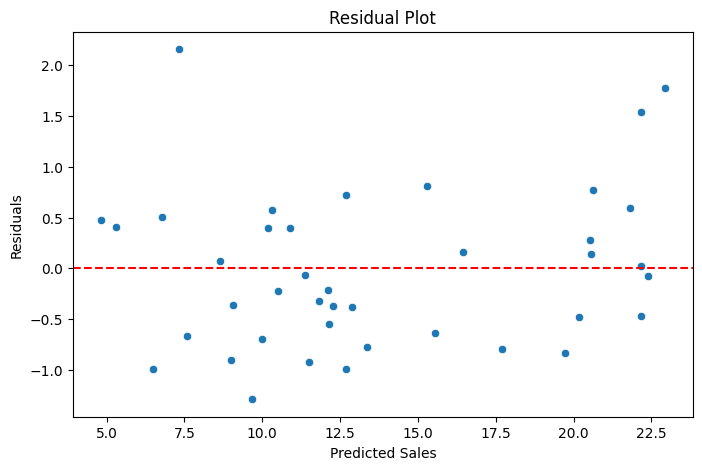

In [33]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=rf_pred,
    y=residuals
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

##  Interpretation: which advertising channel has the highest impact on sales? 

In [31]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,TV Ad Budget ($),0.624810
1,Radio Ad Budget ($),0.362201
2,Newspaper Ad Budget ($),0.012989


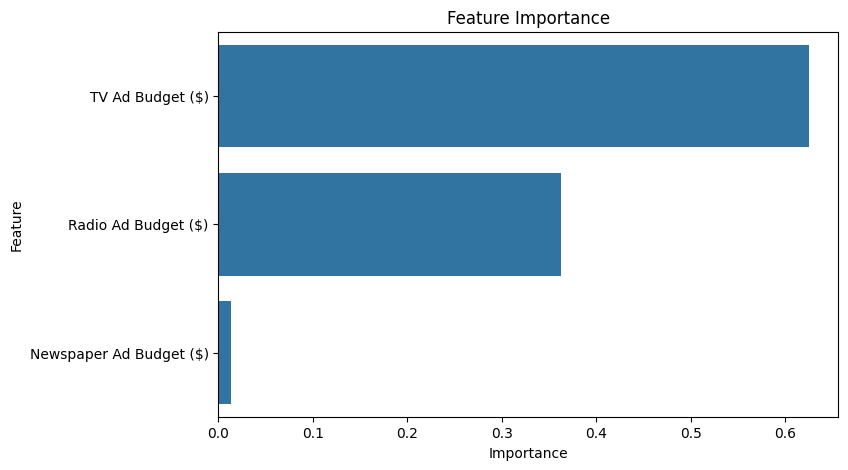

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

## Demo

In [35]:
tv = float(input("Enter TV Ad Budget ($): "))
radio = float(input("Enter Radio Ad Budget ($): "))
newspaper = float(input("Enter Newspaper Ad Budget ($): "))

new_data = pd.DataFrame({
    "TV Ad Budget ($)": [tv],
    "Radio Ad Budget ($)": [radio],
    "Newspaper Ad Budget ($)": [newspaper]
})

prediction = rf.predict(new_data)

print(f"\nPredicted Sales: {prediction[0]:.2f}")

Enter TV Ad Budget ($):  200
Enter Radio Ad Budget ($):  23
Enter Newspaper Ad Budget ($):  34



Predicted Sales: 16.66
